# Car Damage Detection — CarDD → YOLOv8n-seg → Heuristic Severity → Cost Report

**What changed from the pipeline you uploaded, and why:**

- **Dataset**: pulls `CarDD_release.zip` straight from your Google Drive link instead of a Roboflow project (no Roboflow account needed).
- **Detector**: `yolov8n-seg.pt` (a real, publicly available Ultralytics checkpoint) instead of `yolo26s-seg` / SAM2. SAM2 is dropped — YOLOv8-seg already outputs instance masks directly, which removes a heavy dependency and a second model to keep in sync.
- **Severity**: CarDD ships damage *type* labels (dent, scratch, crack, glass shatter, lamp broken, tire flat) but **no severity labels**, so there's no data to train an EfficientNet severity classifier on yet. This notebook uses a simple **mask-area-percentage heuristic** (minor / moderate / severe) as a stand-in, clearly marked so you can swap in a trained classifier once you have severity-labeled crops (Section 8 covers this).
- **Training length**: 20 epochs by default so the whole notebook finishes in well under an hour on a free Colab T4. Bump `EPOCHS` up once you've confirmed everything runs end to end.

Run the cells top to bottom. Runtime → Change runtime type → **GPU** (T4 is fine) before you start.

## 0. Install dependencies

In [1]:
!pip -q install ultralytics opencv-python-headless pillow gdown pycocotools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.5 MB/s eta 0:00:00


## 1. Configuration

The only cell you should need to touch to change behavior.

In [2]:
import os

# ---------------- DATASET ----------------
CARDD_DRIVE_FILE_ID = "1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx"   # from your Google Drive share link
CARDD_ZIP_PATH = "/content/CarDD_release.zip"
CARDD_EXTRACT_DIR = "/content/CarDD_release"
YOLO_DATASET_DIR = "/content/CarDD_yolo"                    # converted YOLO-seg dataset lands here

# ---------------- TRAINING ----------------
EPOCHS = 20          # <<< bump to 100-150 once the pipeline is confirmed working end-to-end
IMG_SIZE = 640
BATCH_SIZE = 8
DEVICE = 0            # Colab GPU index; use "cpu" if you didn't enable a GPU runtime

# ---------------- SEVERITY HEURISTIC ----------------
# % of the image covered by a damage mask -> severity bucket.
# Placeholder until you train a real classifier on labeled severity crops (see Section 8).
SEVERITY_THRESHOLDS = {"minor": 0.5, "moderate": 2.0}  # <0.5% minor, 0.5-2% moderate, >2% severe

# ---------------- TEST IMAGE ----------------
TEST_IMAGE_PATH = None   # leave None to auto-pick a validation image after training, or set your own path

## 2. Download the CarDD dataset from Google Drive

In [3]:
import gdown

os.makedirs("/content", exist_ok=True)
if not os.path.exists(CARDD_ZIP_PATH):
    gdown.download(id=CARDD_DRIVE_FILE_ID, output=CARDD_ZIP_PATH, quiet=False)
else:
    print("Zip already downloaded.")

Downloading...
From (original): https://drive.google.com/uc?id=1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx
From (redirected): https://drive.google.com/uc?id=1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx&confirm=t&uuid=f9a44a9c-86b6-4125-be69-a6237019eb0b
To: /content/CarDD_release.zip
100%|██████████| 6.05G/6.05G [01:42<00:00, 58.9MB/s]


**If the cell above fails or downloads a tiny HTML file instead of the real zip** — Google's virus-scan warning is blocking `gdown` on this large file. Fallback: download `CarDD_release.zip` manually from the link in your browser, upload it to your own Google Drive, then uncomment and run this instead:

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
# CARDD_ZIP_PATH = "/content/drive/MyDrive/CarDD_release.zip"  # <<< adjust to wherever you put it

In [5]:
import zipfile

assert os.path.getsize(CARDD_ZIP_PATH) > 10_000_000, (
    "Downloaded file looks too small to be the real dataset -- gdown probably got a Google Drive "
    "warning page instead of the zip. Use the manual-download fallback above."
)

if not os.path.exists(CARDD_EXTRACT_DIR):
    with zipfile.ZipFile(CARDD_ZIP_PATH, "r") as z:
        z.extractall("/content")
    print("Extracted.")
else:
    print("Already extracted.")

Extracted.


## 3. Locate the COCO annotation files

CarDD's official release ships COCO-format annotations (`instances_train2017.json`, etc.) under a `CarDD_COCO/annotations/` folder, with images in sibling `train2017/ val2017/ test2017/` folders. Layouts inside the zip occasionally shift between releases, so this cell searches for the actual paths rather than assuming.

In [6]:
import glob

coco_jsons = sorted(glob.glob(f"{CARDD_EXTRACT_DIR}/**/*.json", recursive=True))
print("Found annotation files:")
for p in coco_jsons:
    print(" ", p)

TRAIN_JSON = next((p for p in coco_jsons if "train" in p.lower()), None)
VAL_JSON   = next((p for p in coco_jsons if "val" in p.lower()), None)
TEST_JSON  = next((p for p in coco_jsons if "test" in p.lower()), None)

print("\nUsing:\n train:", TRAIN_JSON, "\n val:", VAL_JSON, "\n test:", TEST_JSON)
assert TRAIN_JSON and VAL_JSON, (
    "Couldn't auto-find train/val annotation JSONs -- open the printed list above and set "
    "TRAIN_JSON / VAL_JSON manually to the right paths."
)

Found annotation files:
  /content/CarDD_release/CarDD_COCO/annotations/instances_test2017.json
  /content/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
  /content/CarDD_release/CarDD_COCO/annotations/instances_val2017.json

Using:
 train: /content/CarDD_release/CarDD_COCO/annotations/instances_train2017.json 
 val: /content/CarDD_release/CarDD_COCO/annotations/instances_val2017.json 
 test: /content/CarDD_release/CarDD_COCO/annotations/instances_test2017.json


## 4. Convert COCO annotations to YOLO segmentation format

Ultralytics trains segmentation models from `.txt` label files (one polygon per line, normalized 0-1), not COCO JSON, so we convert. Handles both polygon-style and RLE-style COCO segmentations. Note: if an instance has multiple disjoint polygons (e.g. a scratch split by an occluding part), each polygon is written as a separate line with the same class — a minor simplification that's fine for a prototype.

In [7]:
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils
import cv2, numpy as np, shutil

def ann_to_yolo_polygons(seg, img_w, img_h):
    if isinstance(seg, list):
        polygons = seg
    else:
        rle = maskUtils.frPyObjects(seg, img_h, img_w) if isinstance(seg.get("counts"), list) else seg
        m = maskUtils.decode(rle)
        contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        polygons = [c.flatten().tolist() for c in contours if len(c) >= 6]
    lines = []
    for poly in polygons:
        if len(poly) < 6:
            continue
        norm = []
        for i in range(0, len(poly), 2):
            norm += [poly[i] / img_w, poly[i + 1] / img_h]
        lines.append(norm)
    return lines

def guess_images_dir(json_path):
    base = os.path.dirname(os.path.dirname(json_path))  # .../CarDD_COCO
    split = "train2017" if "train" in json_path.lower() else "val2017" if "val" in json_path.lower() else "test2017"
    candidate = os.path.join(base, split)
    return candidate if os.path.exists(candidate) else base

def convert_split(json_path, split_name, class_id_by_cat):
    coco = COCO(json_path)
    images_src_dir = guess_images_dir(json_path)
    img_out = f"{YOLO_DATASET_DIR}/images/{split_name}"
    lbl_out = f"{YOLO_DATASET_DIR}/labels/{split_name}"
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    n_copied = 0
    for img_id, img_info in coco.imgs.items():
        fname = img_info["file_name"]
        w, h = img_info["width"], img_info["height"]
        src_path = os.path.join(images_src_dir, fname)
        if not os.path.exists(src_path):
            continue
        shutil.copy(src_path, os.path.join(img_out, fname))
        n_copied += 1

        lines = []
        for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
            cid = class_id_by_cat[ann["category_id"]]
            for poly in ann_to_yolo_polygons(ann["segmentation"], w, h):
                lines.append(f"{cid} " + " ".join(f"{v:.6f}" for v in poly))

        label_path = os.path.join(lbl_out, os.path.splitext(fname)[0] + ".txt")
        with open(label_path, "w") as f:
            f.write("\n".join(lines))

    print(f"{split_name}: copied {n_copied} images")

_probe = COCO(TRAIN_JSON)
cat_ids_sorted = sorted(_probe.cats.keys())
class_id_by_cat = {cid: i for i, cid in enumerate(cat_ids_sorted)}
class_names = [_probe.cats[cid]["name"] for cid in cat_ids_sorted]
print("Classes:", class_names)

convert_split(TRAIN_JSON, "train", class_id_by_cat)
convert_split(VAL_JSON, "val", class_id_by_cat)
print("Conversion done ->", YOLO_DATASET_DIR)

loading annotations into memory...
Done (t=0.28s)
creating index...
index created!
Classes: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
train: copied 2816 images
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
val: copied 810 images
Conversion done -> /content/CarDD_yolo


In [8]:
yaml_content = f"path: {YOLO_DATASET_DIR}\ntrain: images/train\nval: images/val\nnames:\n"
for i, name in enumerate(class_names):
    yaml_content += f"  {i}: {name}\n"

with open(f"{YOLO_DATASET_DIR}/data.yaml", "w") as f:
    f.write(yaml_content)
print(yaml_content)

path: /content/CarDD_yolo
train: images/train
val: images/val
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



## 5. Train YOLOv8n-seg

In [9]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n-seg.pt")  # small + fast for a prototype; try yolov8s-seg.pt for more accuracy later

yolo_model.train(
    data=f"{YOLO_DATASET_DIR}/data.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project="car_damage",
    name="yolov8n_seg_prototype",
)

metrics = yolo_model.val()
print("Box mAP50-95:", metrics.box.map, "| Seg mAP50-95:", metrics.seg.map)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscrip

In [11]:
import glob, os

# Search broadly for any best.pt or last.pt produced by this or prior runs
candidates = glob.glob("/content/**/best.pt", recursive=True) + \
             glob.glob("/content/**/last.pt", recursive=True) + \
             glob.glob("**/best.pt", recursive=True) + \
             glob.glob("**/last.pt", recursive=True)

candidates = list(set(candidates))

if not candidates:
    raise FileNotFoundError(
        "No trained weights found anywhere on disk. This means the Colab VM that ran "
        "training is no longer the one you're on now (disconnected/recycled) — the weights "
        "were never persisted anywhere outside that ephemeral disk, so they can't be recovered. "
        "You'll need to retrain (Section 5) and, this time, copy the weights to Google Drive "
        "immediately after training finishes."
    )

# pick the most recently modified one — almost certainly your just-finished run
TRAINED_WEIGHTS = max(candidates, key=os.path.getmtime)
print("Found candidates:", candidates)
print("Using most recent:", TRAINED_WEIGHTS)

yolo = YOLO(TRAINED_WEIGHTS)

Found candidates: ['runs/segment/car_damage/yolov8n_seg_prototype/weights/best.pt', '/content/runs/segment/car_damage/yolov8n_seg_prototype/weights/best.pt', '/content/runs/segment/car_damage/yolov8n_seg_prototype/weights/last.pt', 'runs/segment/car_damage/yolov8n_seg_prototype/weights/last.pt']
Using most recent: runs/segment/car_damage/yolov8n_seg_prototype/weights/best.pt


In [12]:
from google.colab import drive
drive.mount('/content/drive')
import shutil, os
os.makedirs("/content/drive/MyDrive/car_damage_backup", exist_ok=True)
shutil.copy(TRAINED_WEIGHTS, "/content/drive/MyDrive/car_damage_backup/best.pt")
print("Backed up.")

Mounted at /content/drive
Backed up.


## 6. Inference + heuristic severity + cost report

In [13]:
import json

TRAINED_WEIGHTS = "runs/segment/car_damage/yolov8n_seg_prototype/weights/best.pt"
yolo = YOLO(TRAINED_WEIGHTS)

# Rough panel-repair cost table -- replace with your real pricing
COST_TABLE = {
    "dent":          {"minor": 80,  "moderate": 220, "severe": 500},
    "scratch":       {"minor": 50,  "moderate": 150, "severe": 350},
    "crack":         {"minor": 100, "moderate": 300, "severe": 700},
    "glass_shatter": {"minor": 200, "moderate": 400, "severe": 800},
    "lamp_broken":   {"minor": 90,  "moderate": 180, "severe": 300},
    "tire_flat":     {"minor": 60,  "moderate": 120, "severe": 250},
}

def normalize_cls(name):
    return name.strip().lower().replace(" ", "_")

def severity_from_area_pct(area_pct):
    if area_pct < SEVERITY_THRESHOLDS["minor"]:
        return "minor"
    elif area_pct < SEVERITY_THRESHOLDS["moderate"]:
        return "moderate"
    return "severe"

def run_pipeline(image_path, conf=0.35, save_annotated=True):
    image = cv2.imread(image_path)
    h, w = image.shape[:2]
    results = yolo.predict(image_path, conf=conf, verbose=False)[0]

    findings = []
    annotated = image.copy()
    if results.masks is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        classes = results.boxes.cls.cpu().numpy()
        masks = results.masks.data.cpu().numpy()  # (N, mh, mw)

        for box, cls_idx, mask in zip(boxes, classes, masks):
            cls_name = normalize_cls(yolo.names[int(cls_idx)])
            mask_full = cv2.resize(mask, (w, h))
            area_pct = round(100 * float(mask_full.sum()) / (w * h), 3)
            severity = severity_from_area_pct(area_pct)
            cost = COST_TABLE.get(cls_name, {}).get(severity)

            findings.append({
                "damage_type": cls_name,
                "severity": severity,
                "bbox": [int(v) for v in box],
                "area_pct_of_image": area_pct,
                "estimated_repair_cost_usd": cost,
            })

            if save_annotated:
                color = (0, 0, 255)
                overlay = annotated.copy()
                overlay[mask_full > 0.5] = color
                annotated = cv2.addWeighted(overlay, 0.4, annotated, 0.6, 0)
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                cv2.putText(annotated, f"{cls_name} ({severity})", (x1, max(y1 - 8, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    report = {
        "image": image_path,
        "num_findings": len(findings),
        "findings": findings,
        "total_estimated_cost_usd": sum(f["estimated_repair_cost_usd"] or 0 for f in findings),
    }

    if save_annotated:
        out_path = os.path.splitext(image_path)[0] + "_annotated.jpg"
        cv2.imwrite(out_path, annotated)
        report["annotated_image"] = out_path

    return report

## 7. Run it

{
  "image": "/content/CarDD_yolo/images/val/002609.jpg",
  "num_findings": 2,
  "findings": [
    {
      "damage_type": "scratch",
      "severity": "severe",
      "bbox": [
        464,
        172,
        681,
        375
      ],
      "area_pct_of_image": 5.128,
      "estimated_repair_cost_usd": 350
    },
    {
      "damage_type": "dent",
      "severity": "severe",
      "bbox": [
        756,
        156,
        868,
        327
      ],
      "area_pct_of_image": 2.394,
      "estimated_repair_cost_usd": 500
    }
  ],
  "total_estimated_cost_usd": 850,
  "annotated_image": "/content/CarDD_yolo/images/val/002609_annotated.jpg"
}


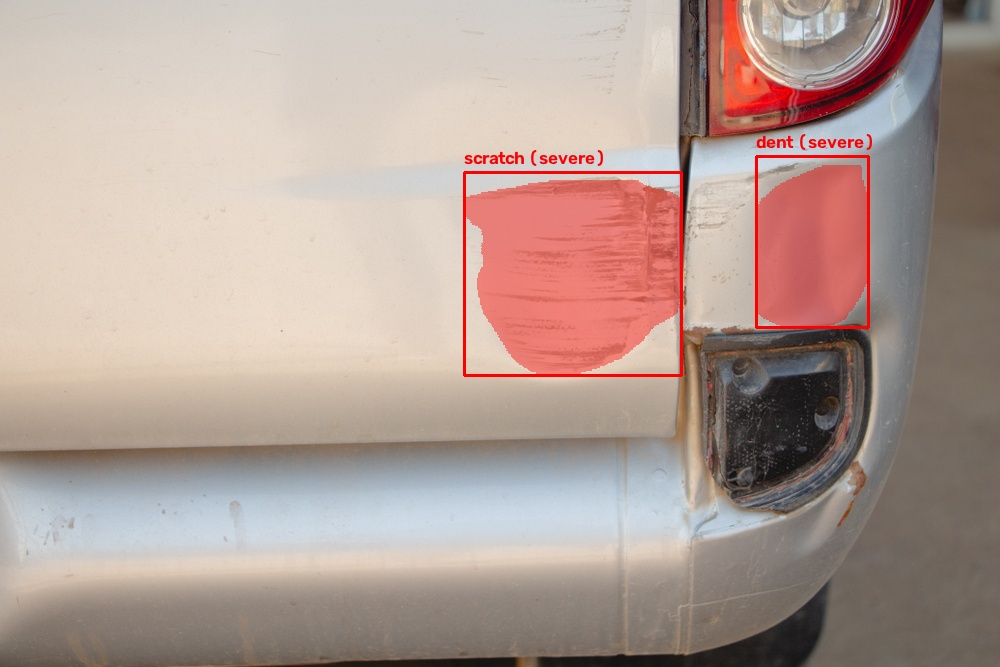

In [14]:
from IPython.display import Image as IPImage, display

if TEST_IMAGE_PATH is None:
    candidates = glob.glob(f"{YOLO_DATASET_DIR}/images/val/*.jpg") + glob.glob(f"{YOLO_DATASET_DIR}/images/val/*.png")
    TEST_IMAGE_PATH = candidates[0] if candidates else None

assert TEST_IMAGE_PATH, "No test image found -- set TEST_IMAGE_PATH manually in Section 1."

report = run_pipeline(TEST_IMAGE_PATH)
print(json.dumps(report, indent=2))
if "annotated_image" in report:
    display(IPImage(filename=report["annotated_image"]))

In [15]:
# Run validation to get precision, recall, mAP metrics
metrics = yolo.val(data=f"{YOLO_DATASET_DIR}/data.yaml")

print("=== Detection (bounding box) metrics ===")
print("Precision:", metrics.box.mp)      # mean precision across classes
print("Recall:   ", metrics.box.mr)      # mean recall across classes
print("mAP50:    ", metrics.box.map50)   # mAP at IoU=0.5
print("mAP50-95: ", metrics.box.map)     # mAP averaged over IoU 0.5:0.95

print("\n=== Segmentation (mask) metrics ===")
print("Precision:", metrics.seg.mp)
print("Recall:   ", metrics.seg.mr)
print("mAP50:    ", metrics.seg.map50)
print("mAP50-95: ", metrics.seg.map)

print("\n=== Per-class breakdown ===")
for i, name in metrics.names.items():
    print(f"{name:15s}  P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}  mAP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3372.3±588.4 MB/s, size: 748.0 KB)
val: Scanning /content/CarDD_yolo/labels/val... 810 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 811/811 1.3Kit/s 0.6s
val: New cache created: /content/CarDD_yolo/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 2.7it/s 19.1s
                   all        811       1744      0.677       0.66      0.684       0.54      0.659      0.663      0.672       0.52
                  dent        352        501       0.65      0.497      0.548      0.305      0.629      0.513      0.535      0.278
               scratch        431        728      0.555      0.479      0.522      0.296      0.549      0.491        0

In [16]:
from google.colab import files
uploaded = files.upload()  # a file picker will pop up — select your images

Saving body-car-get-damaged-by-600nw-190287860.webp to body-car-get-damaged-by-600nw-190287860.webp
Saving OIP (1).webp to OIP (1).webp
Saving OIP.webp to OIP.webp
Saving R.jpeg to R.jpeg



body-car-get-damaged-by-600nw-190287860.jpg
{
  "image": "body-car-get-damaged-by-600nw-190287860.jpg",
  "num_findings": 1,
  "findings": [
    {
      "damage_type": "dent",
      "severity": "severe",
      "bbox": [
        150,
        44,
        492,
        299
      ],
      "area_pct_of_image": 26.125,
      "estimated_repair_cost_usd": 500
    }
  ],
  "total_estimated_cost_usd": 500,
  "annotated_image": "body-car-get-damaged-by-600nw-190287860_annotated.jpg"
}


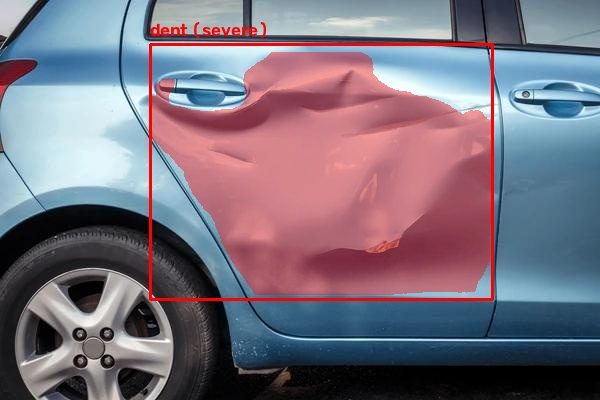


OIP (1).jpg
{
  "image": "OIP (1).jpg",
  "num_findings": 3,
  "findings": [
    {
      "damage_type": "dent",
      "severity": "severe",
      "bbox": [
        367,
        117,
        663,
        300
      ],
      "area_pct_of_image": 4.26,
      "estimated_repair_cost_usd": 500
    },
    {
      "damage_type": "scratch",
      "severity": "severe",
      "bbox": [
        467,
        274,
        854,
        473
      ],
      "area_pct_of_image": 5.765,
      "estimated_repair_cost_usd": 350
    },
    {
      "damage_type": "crack",
      "severity": "moderate",
      "bbox": [
        579,
        587,
        830,
        660
      ],
      "area_pct_of_image": 1.017,
      "estimated_repair_cost_usd": 300
    }
  ],
  "total_estimated_cost_usd": 1150,
  "annotated_image": "OIP (1)_annotated.jpg"
}


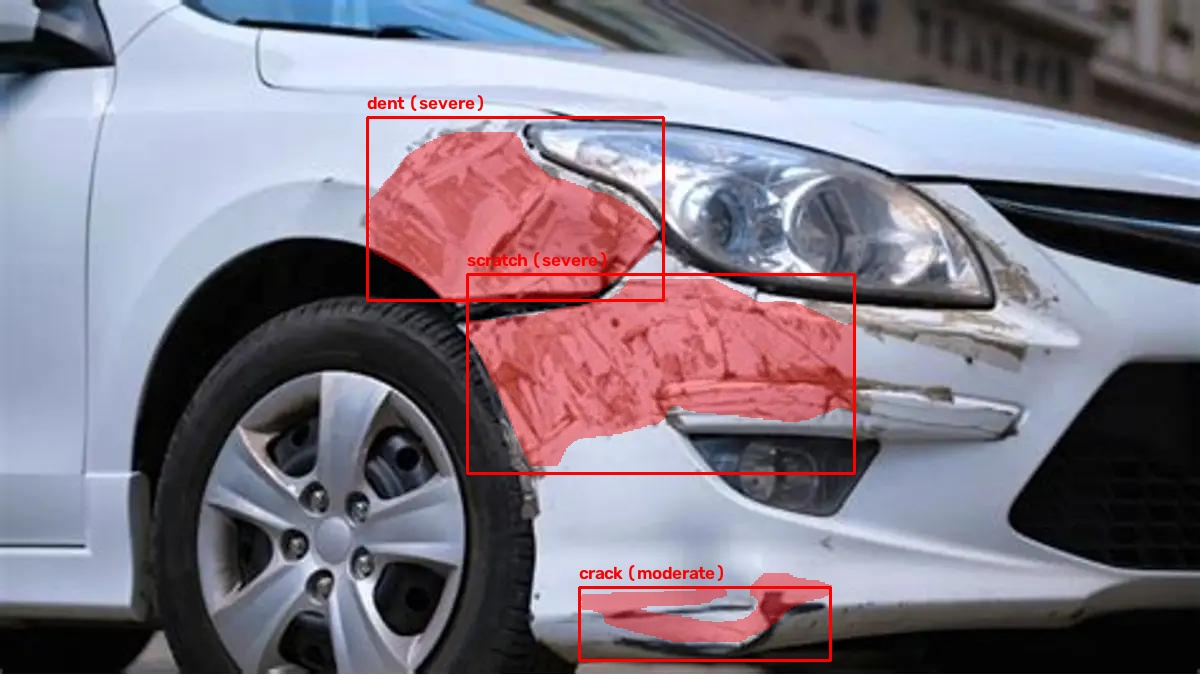


OIP.jpg
{
  "image": "OIP.jpg",
  "num_findings": 1,
  "findings": [
    {
      "damage_type": "dent",
      "severity": "severe",
      "bbox": [
        81,
        84,
        235,
        236
      ],
      "area_pct_of_image": 9.901,
      "estimated_repair_cost_usd": 500
    }
  ],
  "total_estimated_cost_usd": 500,
  "annotated_image": "OIP_annotated.jpg"
}


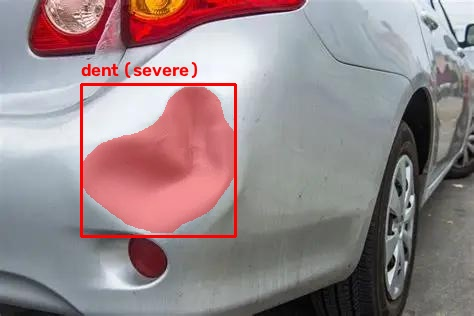


R.jpeg
{
  "image": "R.jpeg",
  "num_findings": 1,
  "findings": [
    {
      "damage_type": "glass_shatter",
      "severity": "severe",
      "bbox": [
        8,
        0,
        1150,
        362
      ],
      "area_pct_of_image": 36.84,
      "estimated_repair_cost_usd": 800
    }
  ],
  "total_estimated_cost_usd": 800,
  "annotated_image": "R_annotated.jpg"
}


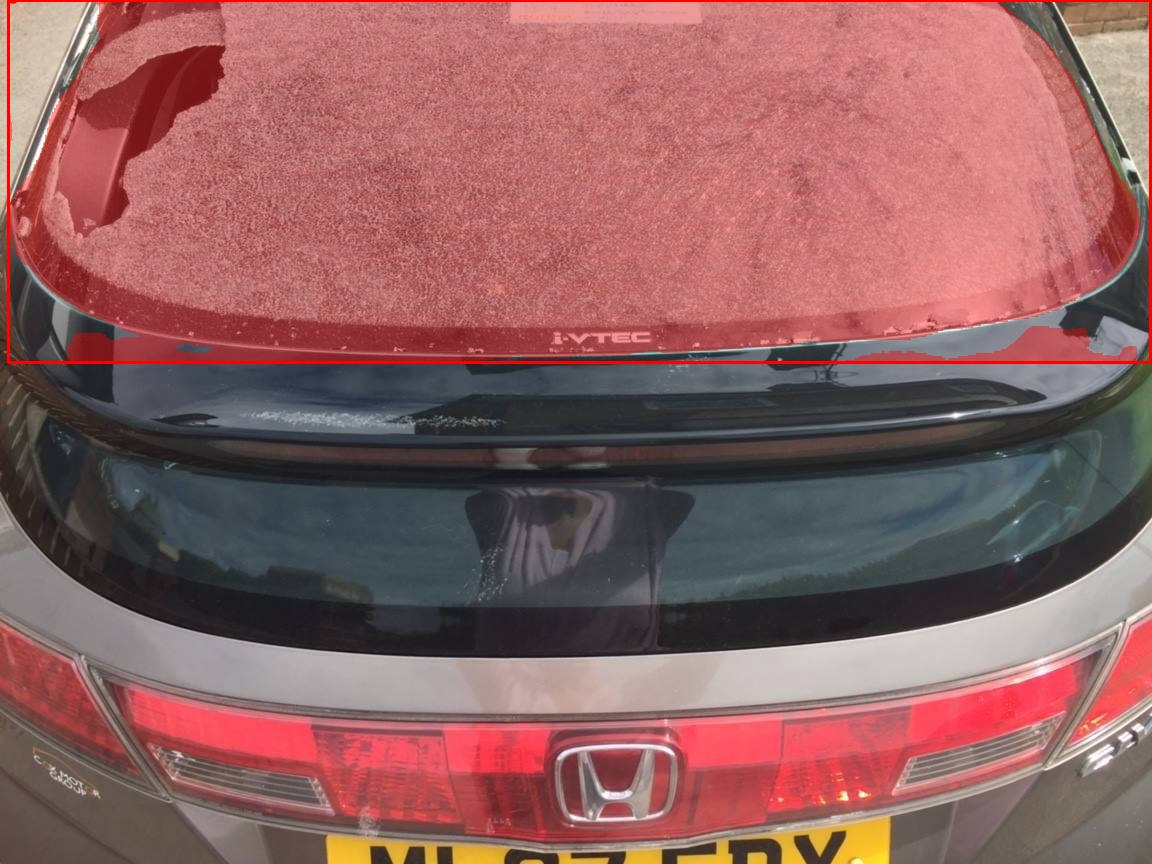

In [17]:
import json, os
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display

# Convert any .webp files to .jpg (cv2 can be unreliable with webp)
converted = []
for fname in uploaded.keys():
    if fname.lower().endswith(".webp"):
        new_name = os.path.splitext(fname)[0] + ".jpg"
        PILImage.open(fname).convert("RGB").save(new_name)
        converted.append(new_name)
    else:
        converted.append(fname)

# Run detection + severity + cost pipeline on each image
for fname in converted:
    print(f"\n{'='*50}\n{fname}\n{'='*50}")
    report = run_pipeline(fname, conf=0.35)
    print(json.dumps(report, indent=2))
    if "annotated_image" in report:
        display(IPImage(filename=report["annotated_image"]))

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

backup_dir = "/content/drive/MyDrive/car_damage_backup"
os.makedirs(backup_dir, exist_ok=True)

weights_dir = "runs/segment/car_damage/yolov8n_seg_prototype/weights"
train_dir   = "runs/segment/car_damage/yolov8n_seg_prototype"

# 1. Model weights (best.pt and last.pt already contain full model + weights)
for fname in ["best.pt", "last.pt"]:
    src = os.path.join(weights_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(backup_dir, fname))
        print(f"Copied {fname}")

# 2. Training config/results for reference (args, metrics, plots)
for fname in ["args.yaml", "results.csv", "results.png", "confusion_matrix.png"]:
    src = os.path.join(train_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(backup_dir, fname))
        print(f"Copied {fname}")

# 3. The dataset's data.yaml (class names / structure) for reproducibility
if os.path.exists(f"{YOLO_DATASET_DIR}/data.yaml"):
    shutil.copy(f"{YOLO_DATASET_DIR}/data.yaml", os.path.join(backup_dir, "data.yaml"))
    print("Copied data.yaml")

print(f"\nAll backed up to: {backup_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied best.pt
Copied last.pt
Copied args.yaml
Copied results.csv
Copied results.png
Copied confusion_matrix.png
Copied data.yaml

All backed up to: /content/drive/MyDrive/car_damage_backup


In [ ]:
#from ultralytics import YOLO
#yolo = YOLO("/content/drive/MyDrive/car_damage_backup/best.pt")

## 8. What to extend first

1. **Train longer / bigger.** 20 epochs on `yolov8n-seg` is enough to prove the pipeline works, not enough for real accuracy. Bump `EPOCHS` to 100-150 and try `yolov8s-seg.pt` or `yolov8m-seg.pt` once you've confirmed the conversion and training loop are correct.
2. **Replace the severity heuristic with a trained classifier.** Crop each detected damage region (`image[y1:y2, x1:x2]` from Section 6), have a few hundred of them labeled minor/moderate/severe, and fine-tune a small CNN (EfficientNet-B0 is a fine choice, as in your original notebook) on those crops. Swap `severity_from_area_pct()` for `severity_model.classify(crop)`.
3. **Calibrate the cost table** against real repair-shop quotes for your target market instead of the placeholder numbers.
4. **Add a low-confidence fallback.** For images where YOLO finds nothing, call a vision-capable LLM (e.g. Gemini or Claude) as a second opinion, the way Section 7 of your original notebook did.
5. **Wrap it as an app.** Once the pipeline is solid, drop `run_pipeline()` behind a Gradio or Streamlit UI (upload a photo -> see the annotated image + JSON report) so it's usable without opening a notebook.
6. **Batch mode.** Loop `run_pipeline()` over a folder of images and write results to a CSV for a fleet/insurance-style bulk report instead of one image at a time.